# Neuro Symbolic Based Deep Learning Model


## Data Collection

1. Import Library

In [1]:
import numpy as np
import pandas as pd
import os
from keras.utils.np_utils import to_categorical
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm  # Importing tqdm for the progress bar
import multiprocessing

2. Set Directory

In [2]:
# Set the base directory where the images and CSV file are located
base_image_dir = r'G:\WQD7023\diabetic-retinopathy-detection\DataNormalizeandResize'  # Updated path for resized images
base_original_dir = r'G:\WQD7023\diabetic-retinopathy-detection\DataOriginal'  # Updated path for original images

# Load the CSV file containing the labels
retina_df = pd.read_csv(os.path.join(base_image_dir, 'Labels', 'trainLabels.csv'))  # Update CSV file path

# Display the first few rows of the dataframe to check the data
print(retina_df.head())

      image  level
0   10_left      0
1  10_right      0
2   13_left      0
3  13_right      0
4   15_left      1


In [3]:
# Create full image paths for both original and normalized images
retina_df['original_path'] = retina_df['image'].map(lambda x: os.path.join(base_original_dir, 'train', '{}.jpeg'.format(x)))
retina_df['normalized_path'] = retina_df['image'].map(lambda x: os.path.join(base_image_dir, 'train', '{}.jpeg'.format(x)))

# Check if the images exist at the given paths
retina_df['original_exists'] = retina_df['original_path'].map(os.path.exists)
retina_df['normalized_exists'] = retina_df['normalized_path'].map(os.path.exists)

# Filter out rows where images do not exist
retina_df = retina_df[retina_df['original_exists'] & retina_df['normalized_exists']]


3. Check image Existense and Extract all Information

In [4]:
# Extract the PatientId from the 'image' column
retina_df['PatientId'] = retina_df['image'].map(lambda x: x.split('_')[0])

# Create full image paths (ensure the image extension is correct, use .jpeg or .jpg as per your dataset)
retina_df['normalize_path'] = retina_df['image'].map(lambda x: os.path.join(base_image_dir, 'train', '{}.jpeg'.format(x)))
retina_df['original_path'] = retina_df['image'].map(lambda x: os.path.join(base_original_dir, 'train', '{}.jpeg'.format(x)))

# Check if the images exist at the given path
retina_df['exists'] = retina_df['normalize_path'].map(os.path.exists)

# Print the number of images found vs the total
print(retina_df['exists'].sum(), 'images found of', retina_df.shape[0], 'total')

# Extract eye information (left = 1, right = 0)
retina_df['eye'] = retina_df['image'].map(lambda x: 1 if x.split('_')[-1] == 'left' else 0)

# Convert the severity level to categorical (one-hot encoding)
retina_df['level_cat'] = retina_df['level'].map(lambda x: to_categorical(x, 1 + retina_df['level'].max()))

# Drop rows with missing values
retina_df.dropna(inplace=True)

# Filter out rows where images do not exist (image paths that do not exist)
retina_df = retina_df[retina_df['exists']]

# Display a sample of the processed dataset
retina_df.sample(10)

35126 images found of 35126 total


,image,level,original_path,normalized_path,original_exists,normalized_exists,PatientId,normalize_path,exists,eye,level_cat
20401,25739_right,0,G:\WQD7023\diabetic-retinopathy-detection\Data...,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,True,25739,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,0,"[1.0, 0.0, 0.0, 0.0, 0.0]"
21514,27103_left,2,G:\WQD7023\diabetic-retinopathy-detection\Data...,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,True,27103,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,1,"[0.0, 0.0, 1.0, 0.0, 0.0]"
33985,42958_right,0,G:\WQD7023\diabetic-retinopathy-detection\Data...,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,True,42958,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,0,"[1.0, 0.0, 0.0, 0.0, 0.0]"
34867,44056_right,0,G:\WQD7023\diabetic-retinopathy-detection\Data...,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,True,44056,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,0,"[1.0, 0.0, 0.0, 0.0, 0.0]"
3212,3992_left,3,G:\WQD7023\diabetic-retinopathy-detection\Data...,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,True,3992,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,1,"[0.0, 0.0, 0.0, 1.0, 0.0]"
657,800_right,0,G:\WQD7023\diabetic-retinopathy-detection\Data...,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,True,800,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,0,"[1.0, 0.0, 0.0, 0.0, 0.0]"
21488,27068_left,0,G:\WQD7023\diabetic-retinopathy-detection\Data...,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,True,27068,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,1,"[1.0, 0.0, 0.0, 0.0, 0.0]"
32977,41658_right,0,G:\WQD7023\diabetic-retinopathy-detection\Data...,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,True,41658,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,0,"[1.0, 0.0, 0.0, 0.0, 0.0]"
20624,25993_left,0,G:\WQD7023\diabetic-retinopathy-detection\Data...,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,True,25993,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,1,"[1.0, 0.0, 0.0, 0.0, 0.0]"
7075,8873_right,0,G:\WQD7023\diabetic-retinopathy-detection\Data...,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,True,8873,G:\WQD7023\diabetic-retinopathy-detection\Data...,True,0,"[1.0, 0.0, 0.0, 0.0, 0.0]"


4. Visualize The image Collected

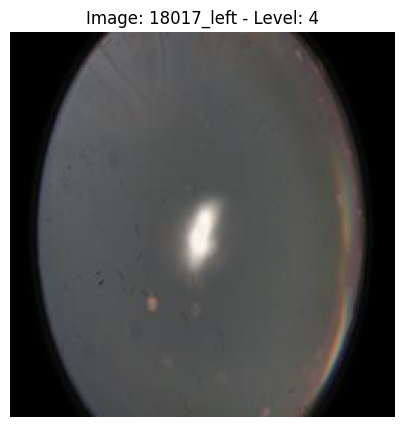

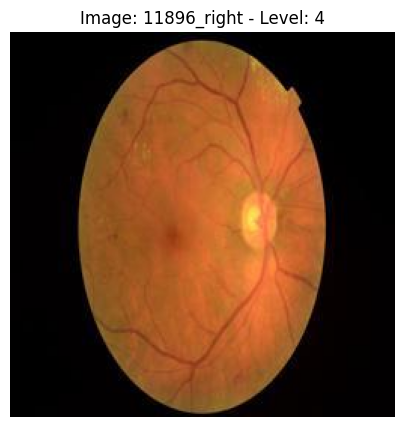

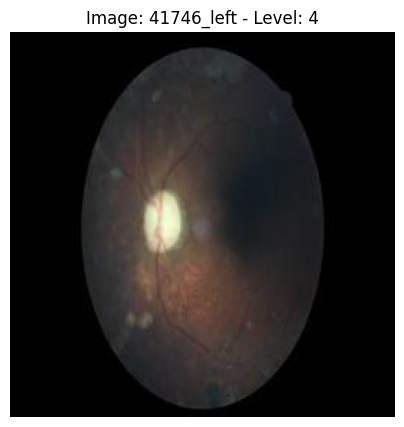

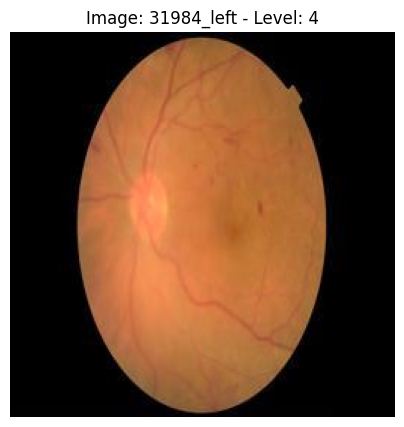

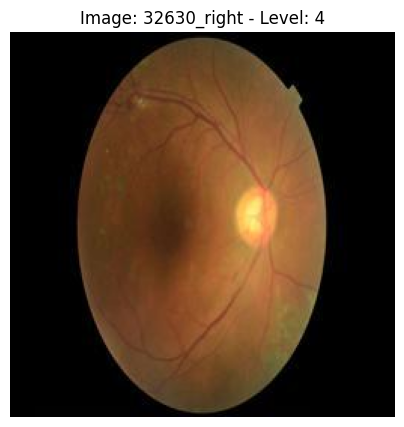

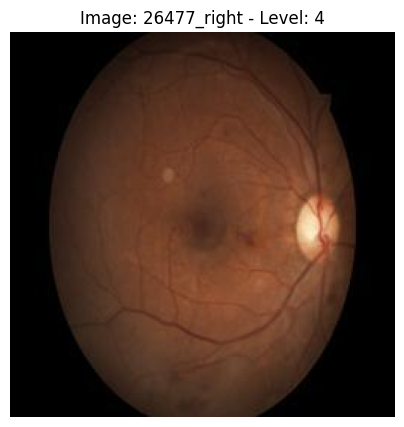

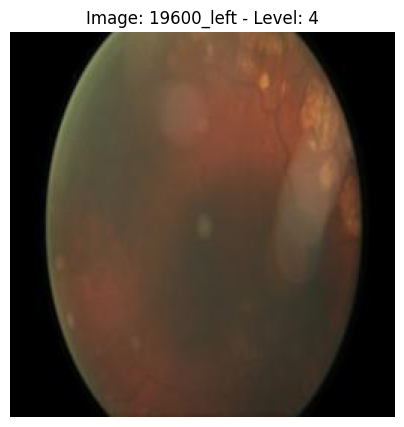

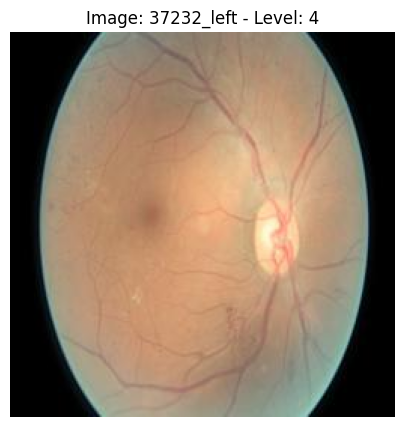

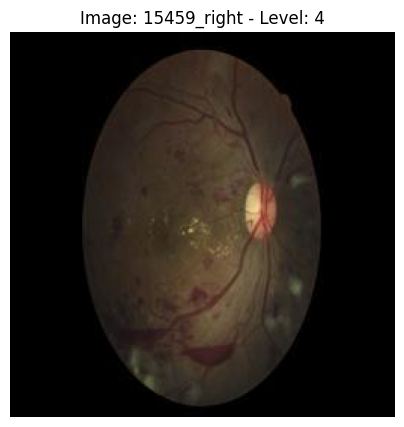

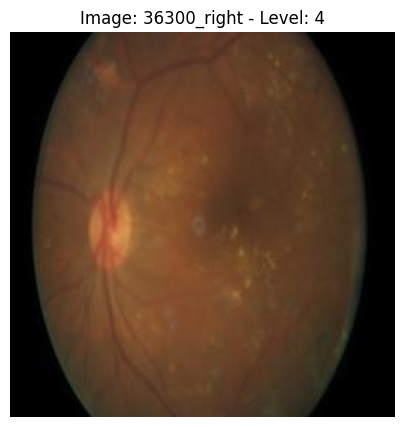

In [5]:
import matplotlib.pyplot as plt  # For visualizing images

# Display a sample of the dataset (random sample)
retina_df.sample(10)

# Filter the dataset for level 0 (severity level 4)
level_0_images = retina_df[retina_df['level'] == 4].sample(10)

# Loop through the filtered dataset and display the images
for index, row in level_0_images.iterrows():
    img_path = row['normalize_path']
    img = Image.open(img_path)
    
    # Display image
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Image: {row['image']} - Level: {row['level']}")
    plt.axis('off')  # Hide axes for better visualization
    plt.show()


## Data Preprocessing

1. Drop Rows with no Image 

In [6]:
# Drop rows with missing values
retina_df.dropna(inplace=True)

# Filter out rows where images do not exist (image paths that do not exist)
retina_df = retina_df[retina_df['exists']]

2. Resize Image (Only Run Once) 

In [6]:
# Resize function to process images one by one
def resize_image(image_path, target_size=(256, 256)):  
    try:
        with Image.open(image_path) as img:
            img_resized = img.resize(target_size)  # Resize image using PIL
            img_resized.save(image_path)  # Save resized image back
            print(f"Successfully resized: {image_path}")
    except Exception as e:
        print(f"Error processing {image_path}: {e}")

In [ ]:
# Go through each image and resize
for img_path in retina_df['normalize_path']:
    resize_image(img_path, target_size=(256, 256))  # Resize to 256x256
    

In [7]:
from PIL import Image
import numpy as np

# Normalization function to process images one by one
def normalize_image(image_path, target_size=(256, 256)):  
    try:
        with Image.open(image_path) as img:
            # Resize if necessary
            img_resized = img.resize(target_size)  # Resize image using PIL (optional)
            
            # Convert the image to numpy array
            img_array = np.array(img_resized)
            
            # Normalize pixel values to [0, 1]
            img_normalized = img_array / 255.0
            
            # Convert normalized numpy array back to PIL image (uint8)
            img_normalized_rescaled = (img_normalized * 255).astype(np.uint8)  # Rescale back to [0, 255]
            img_normalized_pil = Image.fromarray(img_normalized_rescaled)
            
            # Save the normalized image back to the same path (overwrite)
            img_normalized_pil.save(image_path)  # This overwrites the original image
            print(f"Successfully normalized and saved: {image_path}")
            
    except Exception as e:
        print(f"Error processing {image_path}: {e}")




3. Normalize The Image 

In [8]:
# Go through each image and normalize (overwrite the original images)
for img_path in retina_df['normalize_path']:
    normalize_image(img_path, target_size=(256, 256))

Successfully normalized and saved: G:\WQD7023\diabetic-retinopathy-detection\data\train\10_left.jpeg
Successfully normalized and saved: G:\WQD7023\diabetic-retinopathy-detection\data\train\10_right.jpeg
Successfully normalized and saved: G:\WQD7023\diabetic-retinopathy-detection\data\train\13_left.jpeg
Successfully normalized and saved: G:\WQD7023\diabetic-retinopathy-detection\data\train\13_right.jpeg
Successfully normalized and saved: G:\WQD7023\diabetic-retinopathy-detection\data\train\15_left.jpeg
Successfully normalized and saved: G:\WQD7023\diabetic-retinopathy-detection\data\train\15_right.jpeg
Successfully normalized and saved: G:\WQD7023\diabetic-retinopathy-detection\data\train\16_left.jpeg
Successfully normalized and saved: G:\WQD7023\diabetic-retinopathy-detection\data\train\16_right.jpeg
Successfully normalized and saved: G:\WQD7023\diabetic-retinopathy-detection\data\train\17_left.jpeg
Successfully normalized and saved: G:\WQD7023\diabetic-retinopathy-detection\data\train

4. Compare Side by Side

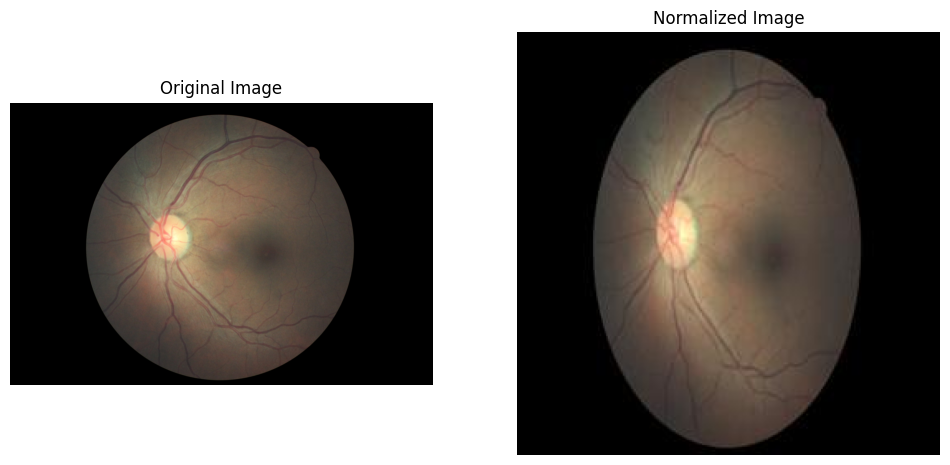

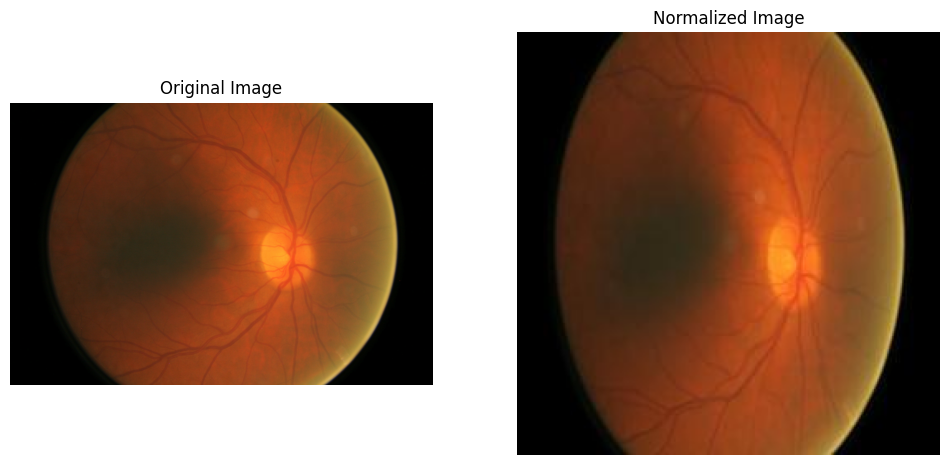

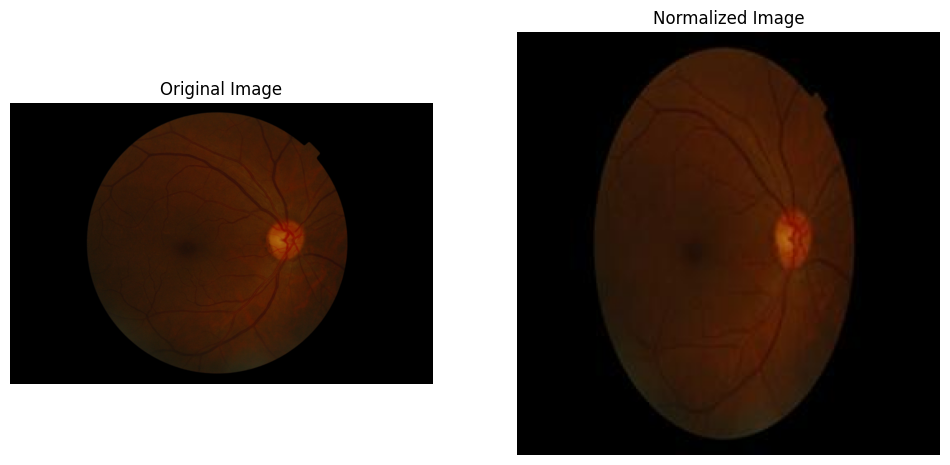

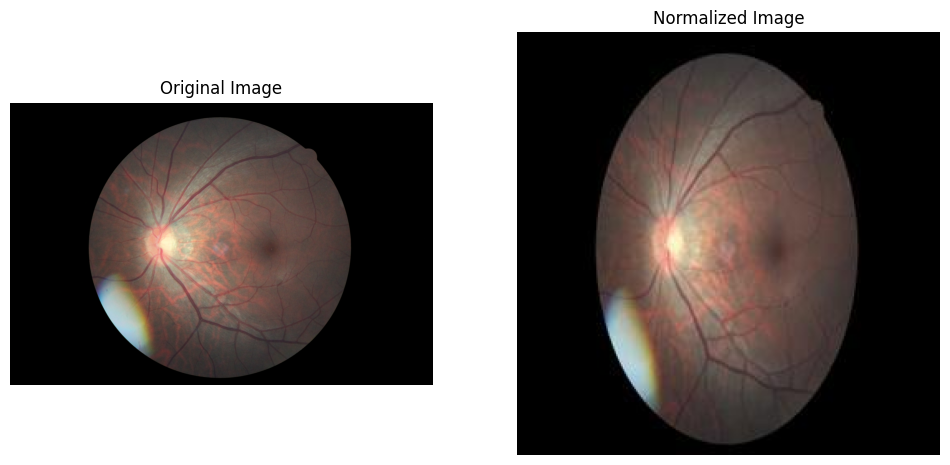

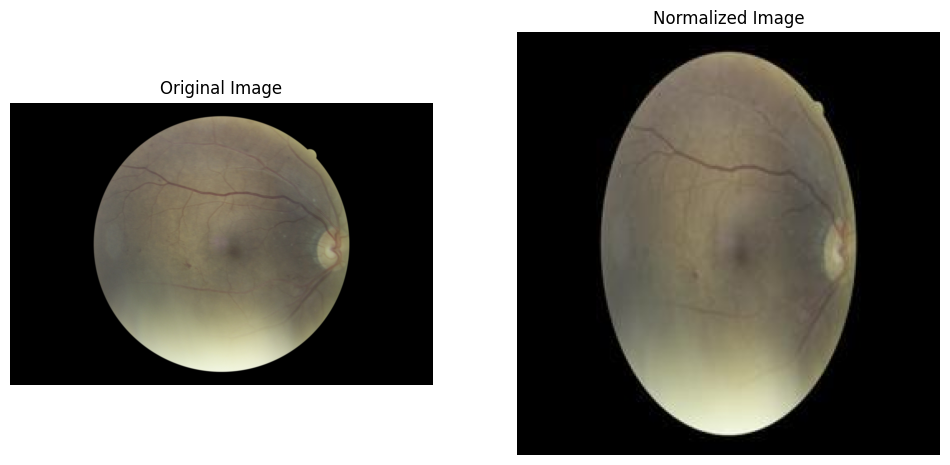

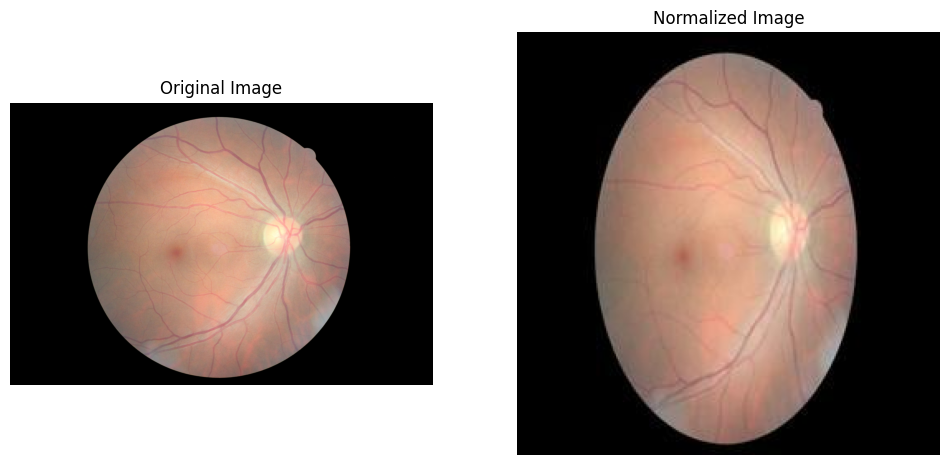

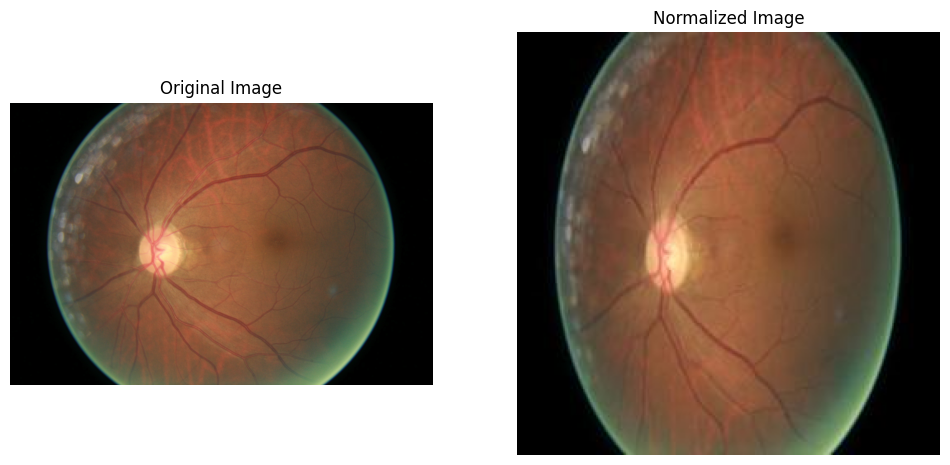

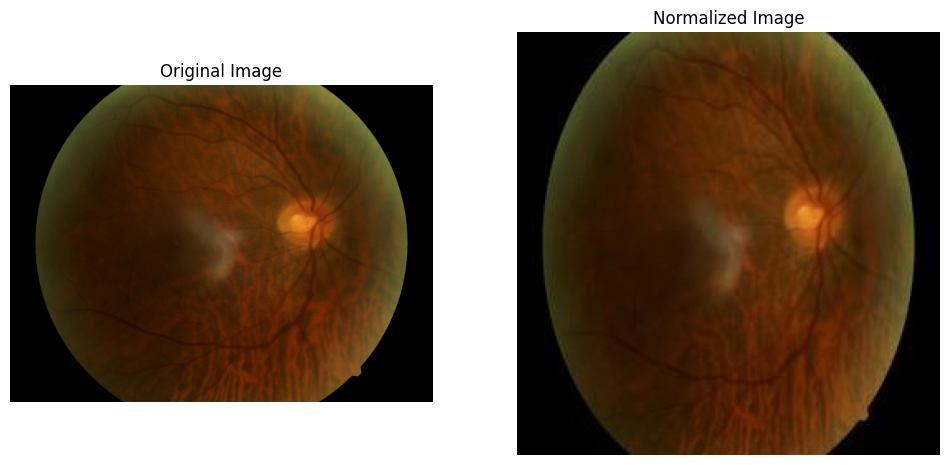

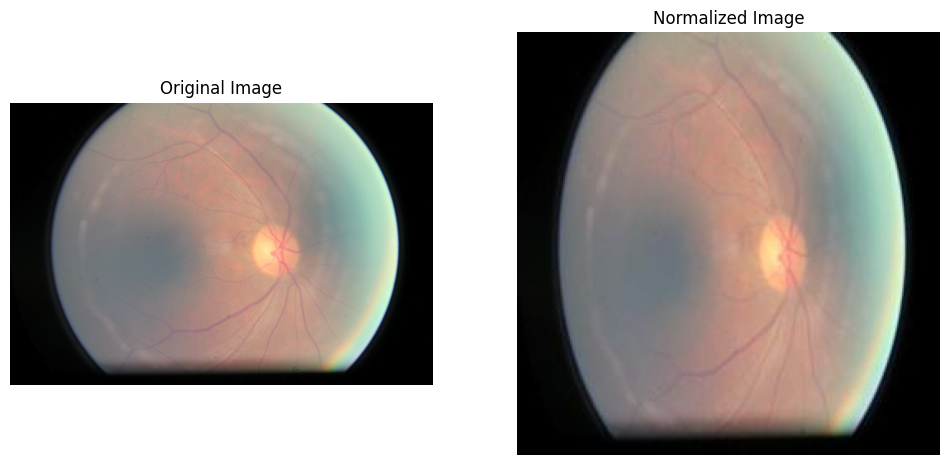

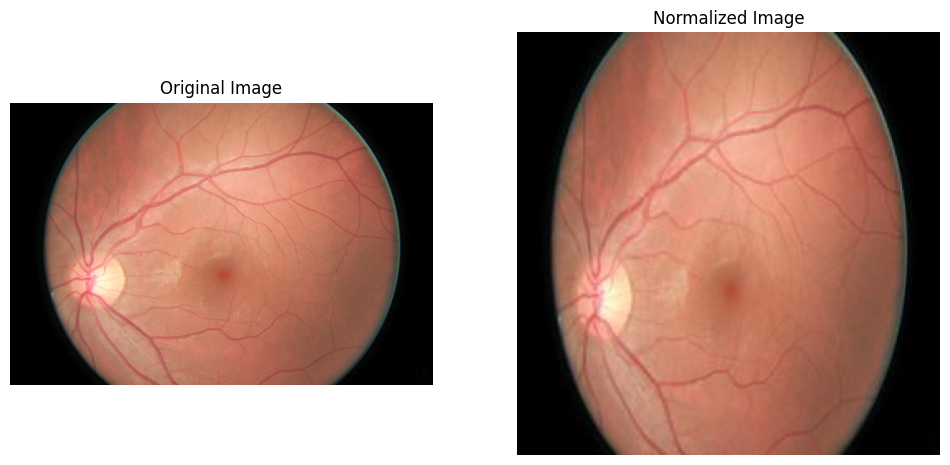

In [7]:
# Function to display original and normalized images side by side for comparison
def display_comparison(original_img, normalized_img):
    # Plot the original and normalized image side by side for comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(original_img)
    axes[0].set_title("Original Image")
    axes[0].axis('off')  # Hide axes for a cleaner look
    
    axes[1].imshow(normalized_img)
    axes[1].set_title("Normalized Image")
    axes[1].axis('off')  # Hide axes for a cleaner look
    
    plt.show()

# Randomly select 10 images from the dataframe
random_images = retina_df.sample(10)

# Display comparison between the original and normalized images (random selection of 10)
for index, row in random_images.iterrows():
    original_img = Image.open(row['original_path'])
    normalized_img = Image.open(row['normalized_path'])
    
    display_comparison(original_img, normalized_img)  # Show before and after comparison